# Mouse Arm Rollout Analysis

This notebook demonstrates how to:
1. Download a pre-trained mouse arm model and reference data from HuggingFace
2. Load the model checkpoint and configure the environment
3. Generate a rollout (simulation) of mouse arm behavior
4. Render and save the rollout as a video
5. Create a timelapse visualization of key frames
6. Analyze joint kinematics by comparing reference motion capture data with the simulated rollout
7. Visualize neural network activations using PCA

The analysis helps validate how well the trained policy reproduces natural mouse arm movement patterns by visualizing both the rendered motion and quantitative joint angle comparisons.

## Imports & Setup

First, we configure the rendering backend and import necessary libraries.

In [25]:
import os
import sys
import numpy as np
import h5py
from tqdm import tqdm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d.art3d import Line3DCollection

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Set rendering backend based on platform
# macOS: use glfw (native OpenGL)
# Linux: use osmesa (software rendering) or egl (headless GPU)
if sys.platform == "darwin":
    os.environ["MUJOCO_GL"] = "glfw"
    print("Using macOS with GLFW rendering")
else:
    # Change this to egl if GPU is available on Linux
    os.environ["MUJOCO_GL"] = "egl"
    print("Using Linux with osmesa rendering")

import mediapy as media
from pathlib import Path

from track_mjx.agent import checkpointing
from track_mjx.analysis import rollout, render

import huggingface_hub as hf_hub
import mujoco
import seaborn as sns

# matplotlib parameters 
mpl.rcParams["figure.facecolor"] = "w"
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 600
mpl.rcParams["savefig.transparent"] = True
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial"]
mpl.rcParams["font.size"] = 8
mpl.rcParams["axes.titlesize"] = "xx-large"  # medium, large, x-large, xx-large
# This might be necessary to export to PDF without messing up the text:
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.style.use("seaborn-v0_8-deep")

def get_joint_qpos(model, qposes, joint_name):
    """Get qpos value(s) for a specific joint by name.
    Args:
        model: The Mujoco model.
        qposes: Array of joint position, shape (n_frames, qpos_dim).
        joint_name: Name of the joint to extract.
    Returns:
        The qpos value(s) for the specified joint
    """
    joint_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, joint_name)
    if joint_id == -1:
        print(f"Joint '{joint_name}' not found!")
        return None

    qpos_addr = model.jnt_qposadr[joint_id]
    joint_type = model.jnt_type[joint_id]

    if joint_type == mujoco.mjtJoint.mjJNT_FREE:
        return qposes[:, qpos_addr : qpos_addr + 7]  # position + quaternion
    elif joint_type == mujoco.mjtJoint.mjJNT_HINGE:
        return qposes[:, qpos_addr]  # single angle
    elif joint_type == mujoco.mjtJoint.mjJNT_BALL:
        return qposes[:, qpos_addr : qpos_addr + 4]  # quaternion
    else:
        return qposes[:, qpos_addr]

Using Linux with osmesa rendering


# Download model from HuggingFace

Download the pre-trained mouse arm model checkpoint from the MIMIC-MJX model repository. This checkpoint contains the trained policy weights and configuration.

In [20]:
hf_checkpoint_path = "arm/control_cost_energy_cost"
model_local_dir = Path.cwd().parent / "model_checkpoints"

# Download model from model repo
model_download_dir = hf_hub.snapshot_download(
    repo_id="talmolab/MIMIC-MJX", 
    repo_type="model", # download from model repo
    allow_patterns=hf_checkpoint_path + "/*", # path with model id
    local_dir=model_local_dir
)
print(f"Downloaded model to {model_download_dir}")

Fetching 24 files: 100%|██████████| 24/24 [00:00<00:00, 798.22it/s]

Downloaded model to /root/vast/eric/track-mjx/model_checkpoints


## Download Reference Data

Download the mouse arm reference clips dataset that contains the motion capture data used for training and evaluation.

In [4]:
import huggingface_hub as hf_hub
from pathlib import Path

# Download all mouse_arm data files
data_local_dir = Path.cwd().parent / "data"
data_download_dir = hf_hub.snapshot_download(
    repo_id="talmolab/MIMIC-MJX", 
    repo_type="dataset", # download from dataset repo
    allow_patterns="data/mouse_arm/*.h5", # download all h5 files in mouse_arm folder
    local_dir=data_local_dir
)
print(f"Downloaded all mouse_arm data to {data_download_dir}")

# List downloaded files
mouse_arm_dir = Path(data_download_dir) / "mouse_arm"
h5_files = list(mouse_arm_dir.glob("*.h5"))

# Print found filenames (for debugging)
#print(f"Found {len(h5_files)} H5 files:")
#for file in sorted(h5_files):
#    print(f"  - {file.name}")

Fetching 46 files: 100%|██████████| 46/46 [00:00<00:00, 808.46it/s]

Downloaded all mouse_arm data to /root/vast/eric/track-mjx/data


# Load checkpoint and configure

Load the checkpoint and update the configuration with the downloaded data path. 

In [5]:
# replace with your checkpoint path
ckpt_path = model_local_dir / hf_checkpoint_path

ckpt = checkpointing.load_checkpoint_for_eval(ckpt_path)
cfg = ckpt["cfg"]

# Update the data path to the downloaded data
cfg.data_path = Path(data_download_dir) / "mouse_arm"

#TEMP: add max_start_frames to cfg to support older checkpoints
#cfg.env_config.env_args.max_start_frame = 0

Loading checkpoint from /root/vast/eric/track-mjx/model_checkpoints/arm/control_cost_energy_cost at step 2


In [6]:
# replace with your checkpoint path
ckpt_path = model_local_dir / hf_checkpoint_path

# Update the data path to include all H5 files as comma-separated string
mouse_arm_dir = Path(data_download_dir) / "mouse_arm"
h5_files = list(mouse_arm_dir.glob("*.h5"))
if h5_files:
    # Create comma-separated list of all files (like in the original config)
    cfg.data_path = ",".join(str(f) for f in sorted(h5_files))
    print(f"Using {len(h5_files)} data files")
else:
    print("No H5 files found!")

#print(f"Data path: {cfg.data_path}")

Using 46 data files


## Create Environment and Rollout Generator

Set up the simulation environment, load the inference function from the trained policy, and create a rollout generator that will produce simulations.

In [7]:
ckpt = checkpointing.load_checkpoint_for_eval(ckpt_path)
cfg = ckpt["cfg"]

# create environment and rollout generator
env = rollout.create_environment(cfg)
inference_fn = checkpointing.load_inference_fn(cfg, ckpt["policy"])
generate_rollout = rollout.create_rollout_generator(
    cfg, 
    env, 
    inference_fn, 
    log_activations=True, 
    log_metrics=True, 
    log_sensor_data=True,
)

Loading checkpoint from /root/vast/eric/track-mjx/model_checkpoints/arm/control_cost_energy_cost at step 2


## Generate Rollout

Generate a single rollout using clip index 3 from the reference data. This will simulate the mouse's reaching behavior based on the trained policy. Feel free to change the clip index to visualize different behaviors in this dataset.

> **Note:** The first time you run this cell, it may take up to 2 minutes to compile the model with JAX, depending on your hardware. Subsequent runs will be much faster. 


In [39]:
# generate a single rollout
single_rollout = generate_rollout(clip_idx=20)

## Render and Save Video

Render the rollout as video frames and save it as an MP4 file. The video will be saved in the checkpoint directory.

In [40]:
# render single rollout 
frames, realtime_framerate = render.render_rollout(
    cfg, 
    single_rollout, 
    height=480,
    width=640,
)

# save the video to disk
media.write_video(Path(ckpt_path) / "rollout.mp4", frames, fps=50)
media.show_video(frames, fps=50)

MuJoCo Rendering with Ghost Model...
Rendering every 1 steps; realtime fps: 500


100%|██████████| 120/120 [00:32<00:00,  3.72it/s]


This browser does not support the video tag.


## Create Timelapse Visualization

Sample every 10th frame from the video and display the first 4 frames in a single row. This provides a quick overview of the fruitfly's behavior progression throughout the rollout.

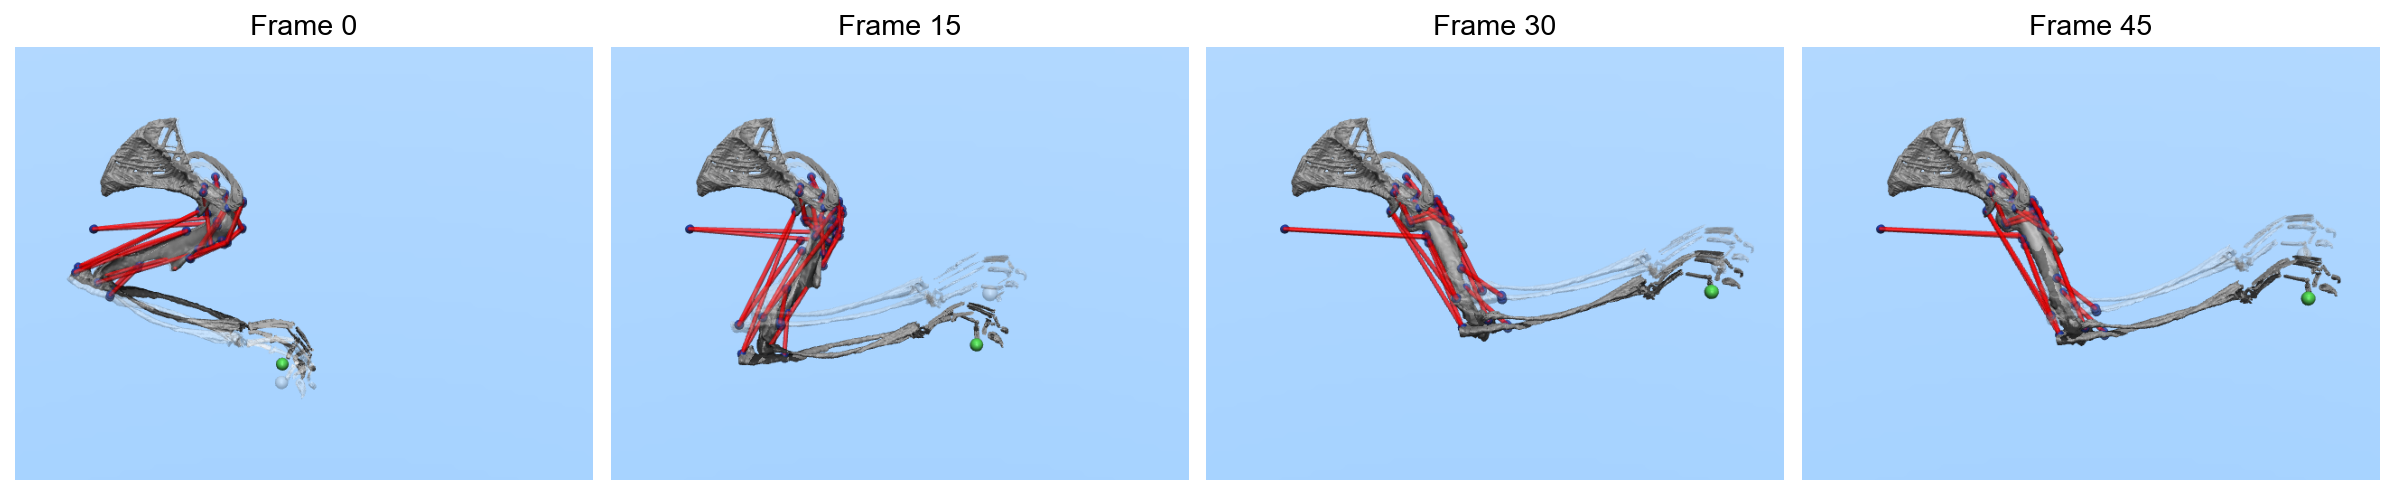

In [41]:
# Create Timelapse Visualization
# Sample every 100th frame and take only 4 frames
sampled_frames = frames[::20][:4]
num_frames = len(sampled_frames)

# Fixed grid dimensions: 1 row, 4 columns
cols = 4
rows = 1

# Create the figure and subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4))
axes = axes.flatten()

# Plot each sampled frame
for idx, frame in enumerate(sampled_frames):
    axes[idx].imshow(frame)
    axes[idx].set_title(f"Frame {idx * 15}")
    axes[idx].axis("off")

# Hide any unused subplots
for idx in range(num_frames, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig(Path(ckpt_path) / "rollout_timelapse_mouse_arm.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualize Rollout Kinematic Statistics

This section analyzes the joint kinematics by comparing the reference motion capture data (STAC Registration) with the simulated rollout (Track Replay). 

We'll plot the joint angles over time for key leg joints (femurs) to assess how accurately the trained policy reproduces the reference motion. The red shaded area highlights the differences between reference and simulated trajectories, providing a visual measure of tracking accuracy.

In [42]:
qposes_ref = single_rollout["qposes_ref"]
qposes_rollout = single_rollout["qposes_rollout"]

qposes_ref.shape, qposes_rollout.shape

((200, 4), (120, 4))

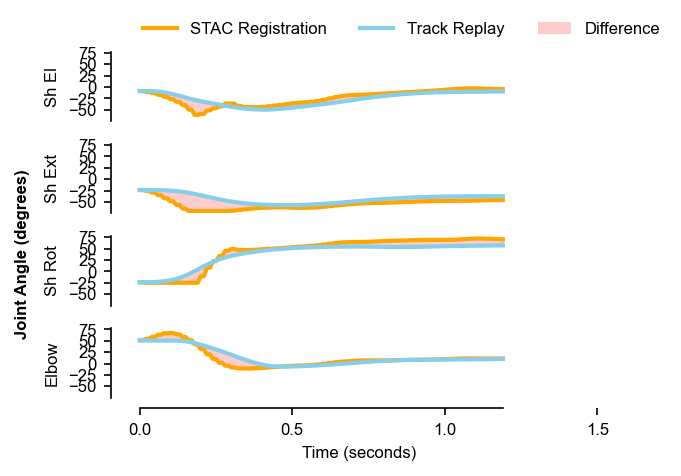

In [44]:
qposes_ref = single_rollout["qposes_ref"]
qposes_rollout = single_rollout["qposes_rollout"]
# Cap the length to the minimum of the two arrays
min_length = min(len(qposes_ref), len(qposes_rollout))
qposes_ref = qposes_ref[:min_length]
qposes_rollout = qposes_rollout[:min_length]
# Create subplots for joint angle comparison
# Create subplots for joint angle comparison
joint_names = [
    "sh_elv",
    "sh_extension",
    "sh_rotation",
    "elbow",
]
joint_labels = [
    "Sh El",
    "Sh Ext",
    "Sh Rot",
    "Elbow",
]

# Set up the subplots
fig, axes = plt.subplots(len(joint_names), 1, figsize=(4, 3), sharex=True)

# First pass: collect all angle data to determine global y-axis limits
all_ref_angles = []
all_rollout_angles = []

for joint_name in joint_names:
    ref_angles = get_joint_qpos(env.sys.mj_model, qposes_ref, f"{joint_name}")
    rollout_angles = get_joint_qpos(env.sys.mj_model, qposes_rollout, f"{joint_name}")

    # Convert from radians to degrees
    ref_angles_deg = np.degrees(ref_angles)
    rollout_angles_deg = np.degrees(rollout_angles)

    all_ref_angles.extend(ref_angles_deg)
    all_rollout_angles.extend(rollout_angles_deg)

# Calculate global y-axis limits with some padding
all_angles = all_ref_angles + all_rollout_angles
y_min = np.min(all_angles) - 5  # Add 5 degree padding
y_max = np.max(all_angles) + 5  # Add 5 degree padding

# Plot each joint in its own subplot
for i, (joint_name, joint_label) in enumerate(zip(joint_names, joint_labels)):
    # Get joint angles for both reference and rollout
    ref_angles = get_joint_qpos(env.sys.mj_model, qposes_ref, f"{joint_name}")
    rollout_angles = get_joint_qpos(env.sys.mj_model, qposes_rollout, f"{joint_name}")

    # Convert from radians to degrees
    ref_angles_deg = np.degrees(ref_angles)
    rollout_angles_deg = np.degrees(rollout_angles)

    # Create time axis
    time_steps = np.arange(len(ref_angles))
    # Convert time steps to seconds (100 Hz = 0.01 seconds per step)
    time_seconds = time_steps * 0.01

    # Plot using seaborn style with solid lines for both
    sns.lineplot(
        x=time_seconds,
        y=ref_angles_deg,
        ax=axes[i],
        color="orange",
        label="STAC Registration",
        linewidth=2,
    )
    sns.lineplot(
        x=time_seconds,
        y=rollout_angles_deg,
        ax=axes[i],
        color="skyblue",
        label="Track Replay",
        linewidth=2,
    )

    # Highlight differences by filling the area between lines
    axes[i].fill_between(
        time_seconds,
        ref_angles_deg,
        rollout_angles_deg,
        alpha=0.2,
        color="red",
    )

    # Customize subplot
    axes[i].set_ylabel(joint_label)

    # Set consistent y-axis limits for all subplots
    axes[i].set_ylim(y_min, y_max)

    # Set informative y-axis ticks
    # Create ticks at nice intervals that include both positive and negative values
    tick_range = y_max - y_min
    if tick_range > 80:
        # For large ranges, use 25-degree intervals
        tick_interval = 25
    elif tick_range > 40:
        # For medium ranges, use 20-degree intervals
        tick_interval = 20
    else:
        # For small ranges, use 10-degree intervals
        tick_interval = 10

    # Generate ticks from the lowest multiple of tick_interval to the highest
    tick_start = int(np.floor(y_min / tick_interval)) * tick_interval
    tick_end = int(np.ceil(y_max / tick_interval)) * tick_interval
    y_ticks = np.arange(tick_start, tick_end + tick_interval, tick_interval)

    # Filter ticks to only show those within our y-limits
    y_ticks = y_ticks[(y_ticks >= y_min) & (y_ticks <= y_max)]
    axes[i].set_yticks(y_ticks)

    # Set informative x-axis ticks in seconds
    max_time = time_seconds[-1]
    if max_time <= 2:
        # For short sequences, use 0.5 second intervals
        x_tick_interval = 0.5
    elif max_time <= 5:
        # For medium sequences, use 1 second intervals
        x_tick_interval = 1.0
    else:
        # For longer sequences, use 2 second intervals
        x_tick_interval = 2.0

    x_ticks = np.arange(0, max_time + x_tick_interval, x_tick_interval)
    axes[i].set_xticks(x_ticks)

    # Remove grid and customize spines
    axes[i].grid(False)
    # For all but the last subplot: remove bottom spine and x-axis ticks
    if i < len(joint_names) - 1:
        sns.despine(ax=axes[i], top=True, right=True, bottom=True, left=False)
        axes[i].tick_params(bottom=False, labelbottom=False)
        # Add gap at bottom of left spine
        axes[i].spines["left"].set_position(("outward", 5))
    else:
        # For the last subplot: keep bottom spine and x-axis
        sns.despine(ax=axes[i], top=True, right=True, bottom=False, left=False)
        # Set x-axis spine to stop at the maximum time
        axes[i].spines["bottom"].set_bounds(0, max_time)
        # Add gap between left and bottom spines
        axes[i].spines["left"].set_position(("outward", 5))
        axes[i].spines["bottom"].set_position(("outward", 5))

    # Remove legends from all subplots
    if axes[i].get_legend():
        axes[i].get_legend().remove()

# Add shared y-axis label
fig.text(
    -0.02,
    0.5,
    "Joint Angle (degrees)",
    va="center",
    rotation="vertical",
    fontweight="bold",
)

# Add manual legend at the upper right with vertical stacking
from matplotlib.patches import Patch

legend_elements = [
    plt.Line2D([0], [0], color="orange", lw=2, label="STAC Registration"),
    plt.Line2D([0], [0], color="skyblue", lw=2, label="Track Replay"),
    Patch(facecolor="red", alpha=0.2, label="Difference"),
]
fig.legend(
    handles=legend_elements,
    loc="upper right",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(1.08, 1.05),  # Fine-tune position
)

# Set common x-axis label
axes[-1].set_xlabel("Time (seconds)")

# Adjust layout to accommodate shared y-label and legend
plt.subplots_adjust(left=0.12, top=0.92)
plt.tight_layout()
plt.show()

## Taking Advantage of Parallel Environment from JAX

JAX enables efficient parallel execution of multiple environment simulations simultaneously. This section demonstrates how to generate rollouts for multiple reference clips in parallel using JAX's `jit` (just-in-time compilation) and `vmap` (vectorized mapping) functions.

**Performance Note:** The parallel rollout generation leverages GPU/TPU acceleration to run multiple environments concurrently, significantly speeding up batch processing compared to sequential execution.

**Memory Considerations:** Adjust the `start_idx` and `end_idx` values based on your available system memory. If you encounter out-of-memory errors, reduce the batch size by narrowing the index range (e.g., process 50 clips at a time instead of 100).

In [45]:
import jax
from jax import numpy as jnp

persistent_cache = True

# you can optionally choose to cache compiled computations to disk
if persistent_cache:
    jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    jax.config.update(
        "jax_persistent_cache_enable_xla_caches",
        "xla_gpu_per_fusion_autotune_cache_dir",
    )


jit_vmap_generate_rollout = jax.jit(jax.vmap(generate_rollout))

## Generate Parallel Rollouts

Generate rollouts for multiple reference clips in parallel using JAX's vectorized execution. This will create simulations for clips indexed from `start_idx` to `end_idx` (exclusive), running all environments simultaneously on GPU/TPU.

The resulting `batch_rollout` dictionary contains the same keys as a single rollout, but with an additional batch dimension corresponding to the number of clips processed in parallel.

In [51]:
start_idx, end_idx = 0, 46
# this will generate rollouts for clip indices in [start_idx, end_idx)
clip_idxs = np.arange(start_idx, end_idx)
batch_rollout = jit_vmap_generate_rollout(clip_idxs)
print("These keys are available in batch_rollout:", list(batch_rollout.keys()))

2025-11-13 18:22:38.762237: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


These keys are available in batch_rollout: ['activations', 'ctrl', 'joint_forces', 'qposes_ref', 'qposes_rollout', 'rollout_metrics', 'sensor_readings', 'state_rewards']


## Batch Rollout Data Structure

The `batch_rollout` dictionary contains the same data as a single rollout, but with an additional batch dimension. The shape of the data is **(batch_dim, timestep, data_dim)**, where:

- **batch_dim**: Number of environments run in parallel (100 clips in this case, from index 0 to 99)
- **timestep**: Number of time steps in each rollout simulation
- **data_dim**: Dimension of the specific data type (e.g., qpos_dim for joint positions, action_dim for controls)

For example, `qposes_rollout` has shape `(100, timesteps, qpos_dim)`, containing the simulated joint positions for all 100 parallel rollouts.

In [52]:
batch_rollout["qposes_rollout"].shape

(46, 120, 4)

In [60]:
batch_rollout["activations"]["decoder"].keys()

dict_keys(['layer_0', 'layer_1', 'layer_2'])

## Neural Network Activation Analysis

This section explores the internal representations learned by the policy network. We'll use Principal Component Analysis (PCA) to visualize the high-dimensional activation space in 2D, revealing the latent structure of the policy's decision-making process throughout the rollout.

In [ ]:
# Define plotting function
def plot_pca_3d(data, color_array, color_bar_label, title, labels):
    """Plot 3D PCA trajectory with color coding"""
    fig = plt.figure(figsize=(5, 3))  # Match reference plot size
    ax = fig.add_subplot(111, projection='3d')
    ax.tick_params(axis="both", which="major", labelsize=8, pad=-4)  # Match reference
    ax.tick_params(axis="z", which="major", labelsize=8, pad=-3)    # Match reference
    
    # Colorbar - match reference styling
    norm = plt.Normalize(np.min(color_array), np.max(color_array))
    cmap = plt.cm.plasma
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)  # Remove pad parameter to match reference
    cbar.set_label(color_bar_label, fontsize=8)  # Match reference font size
    
    # Styling - match reference
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.grid(False)
    # Remove title to match reference (reference doesn't use fig.suptitle)
    
    # Set limits - match reference
    ax.set_xlim(data[:, :, 0].min() - 1, data[:, :, 0].max() + 1)
    ax.set_ylim(data[:, :, 1].min() - 1, data[:, :, 1].max() + 1)
    ax.set_zlim(data[:, :, 2].min() - 1, data[:, :, 2].max() + 1)
    
    # Labels - match reference exactly
    ax.set_xlabel(labels[0], fontsize=8, labelpad=-8, rotation=-16)
    ax.set_ylabel(labels[1], fontsize=8, labelpad=-8, rotation=55)
    ax.set_zlabel(labels[2], fontsize=8, labelpad=-10, rotation=90)
    
    # Plot trajectories - match reference parameters exactly
    for n in range(data.shape[0]):
        d = data[n]
        lc_color = cmap(norm(color_array[n, :-1]))
        line_data = np.stack([d[:-1], d[1:]], axis=1)
        lc = Line3DCollection(line_data, colors=lc_color, linewidths=0.2)  # Match reference
        ax.add_collection3d(lc)
        ax.scatter(d[:, 0], d[:, 1], d[:, 2], c=color_array[n], cmap=cmap, norm=norm, s=6)  # Match reference
    
    plt.tight_layout()
    return fig

Extracting and processing batch rollout data...
Checking data shapes...
Decoder layer 0 shape: (46, 119, 512)
Decoder layer 1 shape: (46, 119, 512)
Decoder layer 2 shape: (46, 119, 512)
Intentions shape: (46, 119, 4)
Qpos rollout shape: (46, 120, 4)
Truncating all data to 119 timesteps
After truncation:
  Decoder layer 0: (46, 119, 512)
  Decoder layer 1: (46, 119, 512)
  Decoder layer 2: (46, 119, 512)
  Intentions: (46, 119, 4)
  Qpos data: (46, 119, 4)
Decoder Layer 0 - Explained variance: [27.2 18.5 14.1]
Decoder Layer 1 - Explained variance: [25.5 15.9 10.8]
Decoder Layer 2 - Explained variance: [55.5 15.7  6.5]
Intentions - Explained variance: [44.3 33.2 20.1]
Intentions - Trajectory data shape: (46, 119, 3)
Intentions - Shoulder angles shape: (46, 119)
Intentions - Shoulder angle range: -0.439 to 1.200 radians
Decoder Layer 1 - Trajectory data shape: (46, 119, 3)
Decoder Layer 1 - Shoulder angles shape: (46, 119)
Decoder Layer 1 - Shoulder angle range: -0.439 to 1.200 radians
De

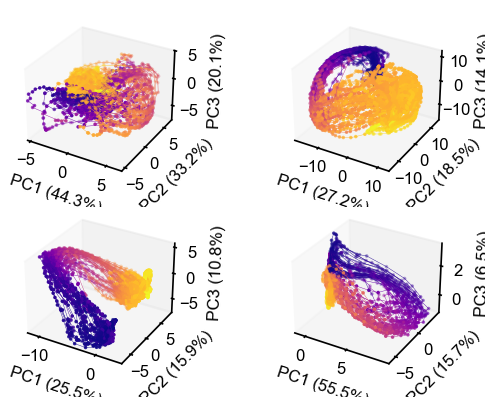

Global shoulder angle range: -0.439 to 1.200 radians


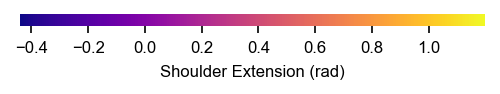

Global shoulder angle range: -0.439 to 1.200 radians


In [62]:
# Create a 2x2 subplot layout for all decoder layers and intentions using batch rollout data
from matplotlib.figure import Figure
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from typing import List
import numpy as np
from sklearn.decomposition import PCA

def plot_subplot(
    data: np.ndarray,
    color_array: np.ndarray,
    title: str,
    labels: List[str],
    ax,
    norm,
    cmap,
):
    """
    Plot a 3D trajectory with color-coded points and connecting line segments on a given axis.
    """
    ax.tick_params(axis="both", which="major", labelsize=8, pad=-4)
    ax.tick_params(axis="z", which="major", labelsize=8, pad=-3)

    # make the overall figure background white
    ax.set_facecolor("white")
    ax.grid(False)  # remove grid lines

    # RESTORED: Use the tight axis limits from your original (this prevents zooming out)
    x_range = data[:, :, 0].max() - data[:, :, 0].min()
    y_range = data[:, :, 1].max() - data[:, :, 1].min()
    z_range = data[:, :, 2].max() - data[:, :, 2].min()

    ratio = -0.005

    ax.set_xlim(
        data[:, :, 0].min() - x_range * ratio, data[:, :, 0].max() + x_range * ratio
    )
    ax.set_ylim(
        data[:, :, 1].min() - y_range * ratio, data[:, :, 1].max() + y_range * ratio
    )
    ax.set_zlim(
        data[:, :, 2].min() - z_range * ratio, data[:, :, 2].max() + z_range * ratio
    )

    # add axis labels - match single plot styling exactly
    ax.set_xlabel(labels[0], fontsize=8, labelpad=-8, rotation=-16)
    ax.set_ylabel(labels[1], fontsize=8, labelpad=-8, rotation=55)
    ax.set_zlabel(labels[2], fontsize=8, labelpad=-8, rotation=90)

    # RESTORED: Use your original scatter size and linewidth
    for n in range(data.shape[0]):
        # define line color
        d = data[n]
        lc_color = cmap(norm(color_array[n, :-1]))
        line_data = np.stack([d[:-1], d[1:]], axis=1)
        lc = Line3DCollection(line_data, colors=lc_color, linewidths=0.2)  # Match original
        ax.add_collection3d(lc)
        ax.scatter(
            d[:, 0], d[:, 1], d[:, 2], c=color_array[n], cmap=cmap, norm=norm, s=0.5  # Match original s=0.5
        )

# Extract and process data from batch rollout for PCA analysis
print("Extracting and processing batch rollout data...")

def perform_pca_batch(data, layer_name):
    """Perform PCA on batch activation data"""
    pca = PCA(n_components=3)
    
    # Concatenate all batch data into one long array
    concatenated_data = data.reshape(-1, data.shape[-1])  # Shape: (batch*timesteps, features)
    pca_result = pca.fit_transform(concatenated_data)
    
    # Reshape back to original batch structure
    batch_size, timesteps, _ = data.shape
    pca_result = pca_result.reshape(batch_size, timesteps, 3)
    
    explained_variance = np.round(pca.explained_variance_ratio_ * 100, 1)
    print(f"{layer_name} - Explained variance: {explained_variance}")
    return pca_result, explained_variance

# Extract data directly from batch_rollout
print("Checking data shapes...")
decoder_layer_0_data = batch_rollout["activations"]["decoder"]["layer_0"]
decoder_layer_1_data = batch_rollout["activations"]["decoder"]["layer_1"] 
decoder_layer_2_data = batch_rollout["activations"]["decoder"]["layer_2"]
intentions_data = batch_rollout["activations"]["intention"]
qpos_data = batch_rollout["qposes_rollout"]

print(f"Decoder layer 0 shape: {decoder_layer_0_data.shape}")
print(f"Decoder layer 1 shape: {decoder_layer_1_data.shape}")
print(f"Decoder layer 2 shape: {decoder_layer_2_data.shape}")
print(f"Intentions shape: {intentions_data.shape}")
print(f"Qpos rollout shape: {qpos_data.shape}")

# Find the minimum timestep length across all data  
min_timesteps = min(
    decoder_layer_0_data.shape[1],
    decoder_layer_1_data.shape[1], 
    decoder_layer_2_data.shape[1],
    intentions_data.shape[1],
    qpos_data.shape[1]
)

print(f"Truncating all data to {min_timesteps} timesteps")

# Truncate all arrays to the same timestep length
decoder_layer_0_truncated = decoder_layer_0_data[:, :min_timesteps, :]
decoder_layer_1_truncated = decoder_layer_1_data[:, :min_timesteps, :]
decoder_layer_2_truncated = decoder_layer_2_data[:, :min_timesteps, :]
intentions_truncated = intentions_data[:, :min_timesteps, :]
qpos_data_truncated = qpos_data[:, :min_timesteps, :]

print(f"After truncation:")
print(f"  Decoder layer 0: {decoder_layer_0_truncated.shape}")
print(f"  Decoder layer 1: {decoder_layer_1_truncated.shape}")
print(f"  Decoder layer 2: {decoder_layer_2_truncated.shape}")
print(f"  Intentions: {intentions_truncated.shape}")
print(f"  Qpos data: {qpos_data_truncated.shape}")

# Perform PCA on all layers
decoder_layer_0, vars_decoder_layer_0 = perform_pca_batch(decoder_layer_0_truncated, "Decoder Layer 0")
decoder_layer_1, vars_decoder_layer_1 = perform_pca_batch(decoder_layer_1_truncated, "Decoder Layer 1")
decoder_layer_2, vars_decoder_layer_2 = perform_pca_batch(decoder_layer_2_truncated, "Decoder Layer 2")
intentions_pca, vars_intentions_pca = perform_pca_batch(intentions_truncated, "Intentions")

# Convert to numpy arrays for concatenation
qpos_data_truncated = np.array(qpos_data_truncated)

# Create data with shoulder extension angle as 4th dimension using truncated data
decoder_0_with_angle = np.concatenate([decoder_layer_0, qpos_data_truncated[:, :, 2][..., np.newaxis]], axis=2)
decoder_1_with_angle = np.concatenate([decoder_layer_1, qpos_data_truncated[:, :, 2][..., np.newaxis]], axis=2)
decoder_2_with_angle = np.concatenate([decoder_layer_2, qpos_data_truncated[:, :, 2][..., np.newaxis]], axis=2)
intentions_with_angle = np.concatenate([intentions_pca, qpos_data_truncated[:, :, 2][..., np.newaxis]], axis=2)

# Dataset configurations using computed variables
datasets = {
    "intentions": {
        "data": intentions_with_angle,
        "title": "Intentions",
        "var_exp": vars_intentions_pca,
    },
    "decoder_layer_0": {
        "data": decoder_0_with_angle,
        "title": "Decoder Layer 1",
        "var_exp": vars_decoder_layer_0,
    },
    "decoder_layer_1": {
        "data": decoder_1_with_angle,
        "title": "Decoder Layer 2",
        "var_exp": vars_decoder_layer_1,
    },
    "decoder_layer_2": {
        "data": decoder_2_with_angle,
        "title": "Decoder Layer 3",
        "var_exp": vars_decoder_layer_2,
    },
}

# Find global min and max across all shoulder angles for consistent colorbar
all_shoulder_angles = []
for config in datasets.values():
    shoulder_angles = config["data"][:, :, 3]
    all_shoulder_angles.append(shoulder_angles)

global_min = min(angles.min() for angles in all_shoulder_angles)
global_max = max(angles.max() for angles in all_shoulder_angles)

# Create shared colormap and normalization
norm = plt.Normalize(global_min, global_max)
cmap = plt.cm.plasma

# Create 2x2 subplot figure
fig = plt.figure(figsize=(3.75, 3))
fig.patch.set_facecolor("white")

subplot_positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for i, (key, config) in enumerate(datasets.items()):
    row, col = subplot_positions[i]
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")

    plot_data = config["data"]
    var_exp = config["var_exp"]

    # Extract the 3D coordinates (first 3 dimensions) and shoulder extension angle (4th dimension)
    trajectory_data = plot_data[:, :, :3]  # Shape: (N, T, 3) - x, y, z coordinates
    shoulder_angles = plot_data[:, :, 3]  # Shape: (N, T) - shoulder extension angles

    # Create labels with explained variance percentages
    labels = [f"PC1 ({var_exp[0]:.1f}%)", f"PC2 ({var_exp[1]:.1f}%)", f"PC3 ({var_exp[2]:.1f}%)"]

    # Plot the 3D trajectory with shoulder extension angle as color
    plot_subplot(
        data=trajectory_data,
        color_array=shoulder_angles,
        title=config["title"],
        labels=labels,
        ax=ax,
        norm=norm,
        cmap=cmap,
    )

    # Fix ticks only for the top-left subplot (intentions)
    if key == "intentions":
        ax.set_xticks([-5, 0, 5])
        ax.set_yticks([-5, 0, 5])
        ax.set_zticks([-5, 0, 5])

    print(f"{config['title']} - Trajectory data shape: {trajectory_data.shape}")
    print(f"{config['title']} - Shoulder angles shape: {shoulder_angles.shape}")
    print(
        f"{config['title']} - Shoulder angle range: {shoulder_angles.min():.3f} to {shoulder_angles.max():.3f} radians"
    )

# Use subplots_adjust instead of tight_layout to add whitespace between rows
plt.subplots_adjust(
    left=0.00,     # Left margin
    right=0.95,    # Right margin
    top=0.90,      # Top margin
    bottom=0.10,   # Bottom margin
    wspace=0.0,   # Width spacing between columns (left-right)
    hspace=0.15    # Height spacing between rows (top-bottom) - this adds the whitespace!
)

plt.savefig("arm_latent_space_2x2_batch.pdf", pad_inches=0.2)
plt.show()

print(f"Global shoulder angle range: {global_min:.3f} to {global_max:.3f} radians")

# Create a separate figure for the colorbar
fig_cbar, ax_cbar = plt.subplots(figsize=(4, 0.1))
fig_cbar.patch.set_facecolor("white")

# Create the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax_cbar, orientation="horizontal")
plt.tick_params(labelsize=8)
cbar.set_label("Shoulder Extension (rad)", fontsize=8)

# Remove the axis frame
ax_cbar.set_frame_on(False)
plt.savefig("fig5_arm_latent_space_colorbar_batch.pdf", bbox_inches="tight")
plt.show()

print(f"Global shoulder angle range: {global_min:.3f} to {global_max:.3f} radians")